In [20]:
%run base.ipynb

mare


**Naive bound!** Theorem 2.5

[checkpoint] bound: "naive" -> bound_naive, params: []


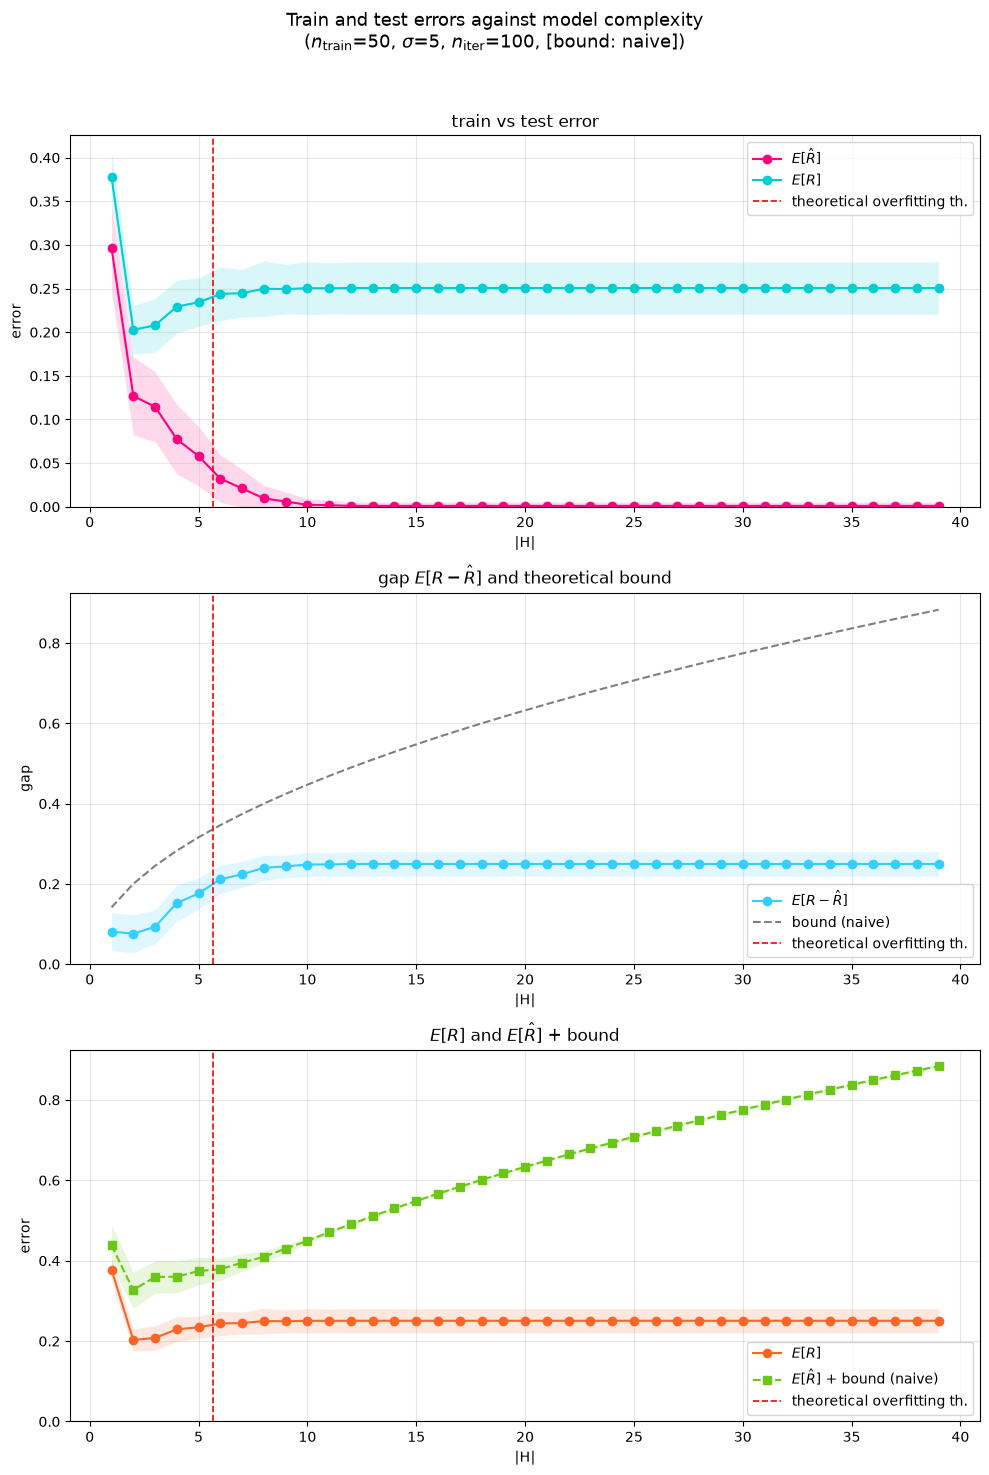

' \nRunning time: <1min\n'

In [14]:
# MODEL
mymodel = DecisionTreeClassifier

# PARAMETERS
N = 10_000
n_test = 200_000
n = 50
noise_std = 5
T = 100

# build test set
x_test = sample_x(n_test, N)
y_test = sample_y(x = x_test, f = centered_parabola, sigma = noise_std)

# build models and do plots
hat_Rs, Rs, gaps, std_hat_Rs, std_Rs, std_gaps, predictions, x, y, x_grid = main_loop(
    x_test, y_test, n_train = n, sigma = noise_std, num_iter = T, model = mymodel
    )
plots(hat_Rs, Rs, gaps, std_hat_Rs=std_hat_Rs, std_Rs=std_Rs, std_gaps=std_gaps, 
      n_train = n, sigma = noise_std, num_iter= T, model = mymodel, 
      bound_name = "naive", bound_params = {}
      )

''' 
Running time: <1min
'''

**Bound with variance!** Equation (46)

[checkpoint] bound: "variance_trainerr" -> bound_variance_trainerror, params: ['Rhat']


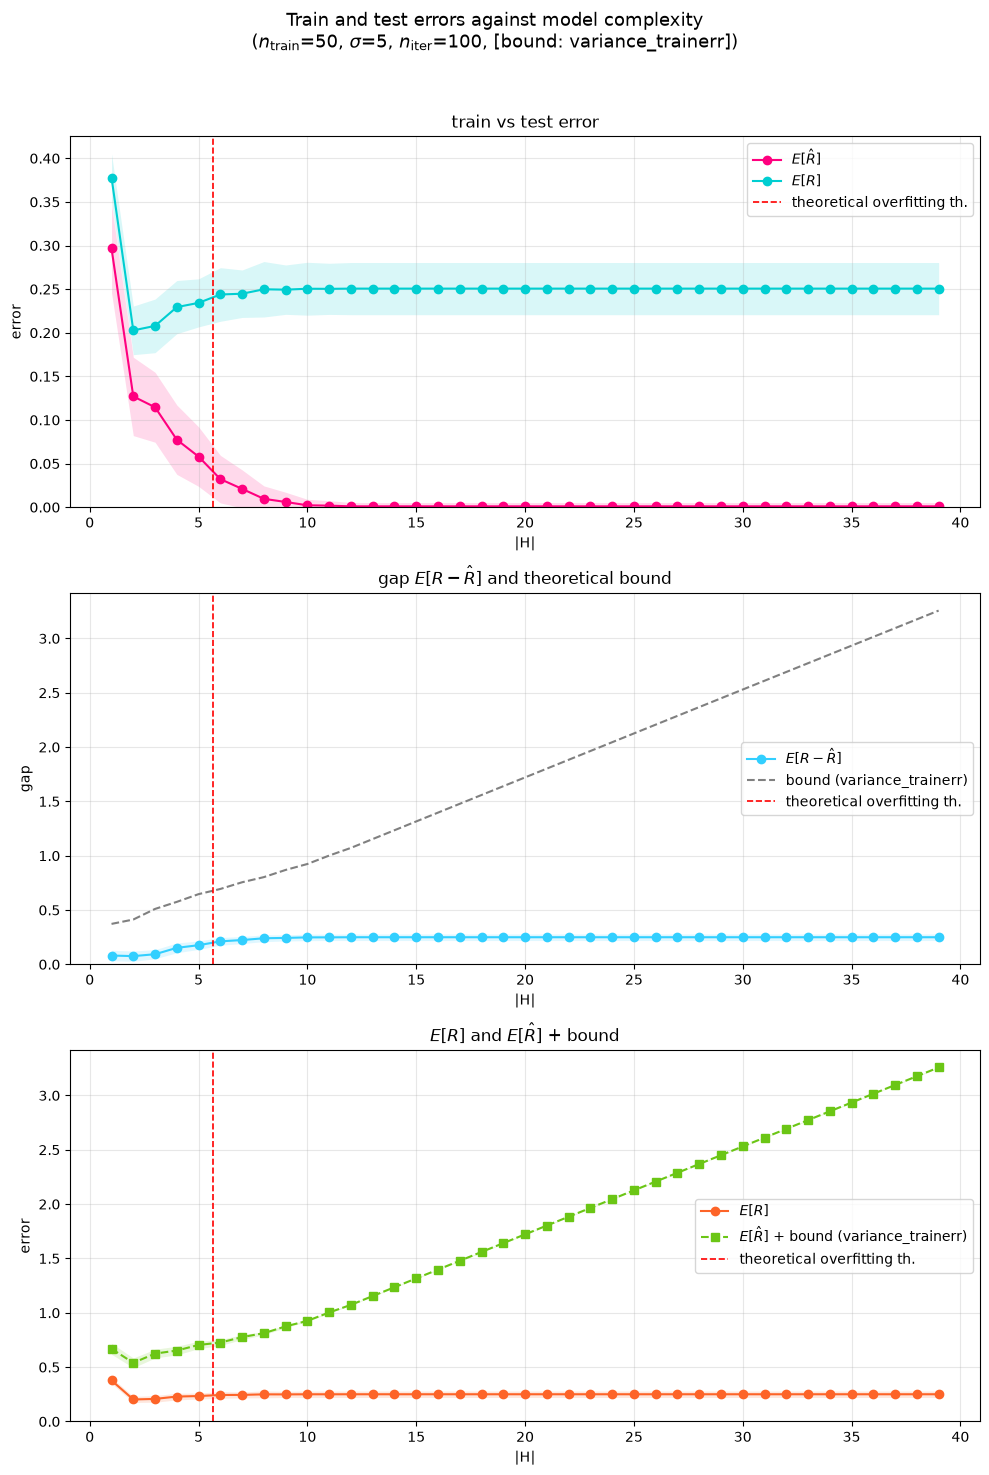

' \nRunning time: <1min\n'

In [16]:
# MODEL
mymodel = DecisionTreeClassifier

# PARAMETERS
N = 10_000
n_test = 200_000
n = 50
noise_std = 5
T = 100

# build test set
x_test = sample_x(n_test, N)
y_test = sample_y(x = x_test, f = centered_parabola, sigma = noise_std)

# build models and do plots
hat_Rs, Rs, gaps, std_hat_Rs, std_Rs, std_gaps, predictions, x, y, x_grid = main_loop(
    x_test, y_test, n_train = n, sigma = noise_std, num_iter = T, model = mymodel
    )
plots(hat_Rs, Rs, gaps, std_hat_Rs=std_hat_Rs, std_Rs=std_Rs, std_gaps=std_gaps, 
      n_train = n, sigma = noise_std, num_iter= T, model = mymodel, 
      bound_name = "variance_trainerr", bound_params = {"Rhat": hat_Rs}
      )

''' 
Running time: <1min
'''

#### Sine function for generating data

**Naive bound!** Theorem 2.5

[checkpoint] bound: "naive" -> bound_naive, params: []


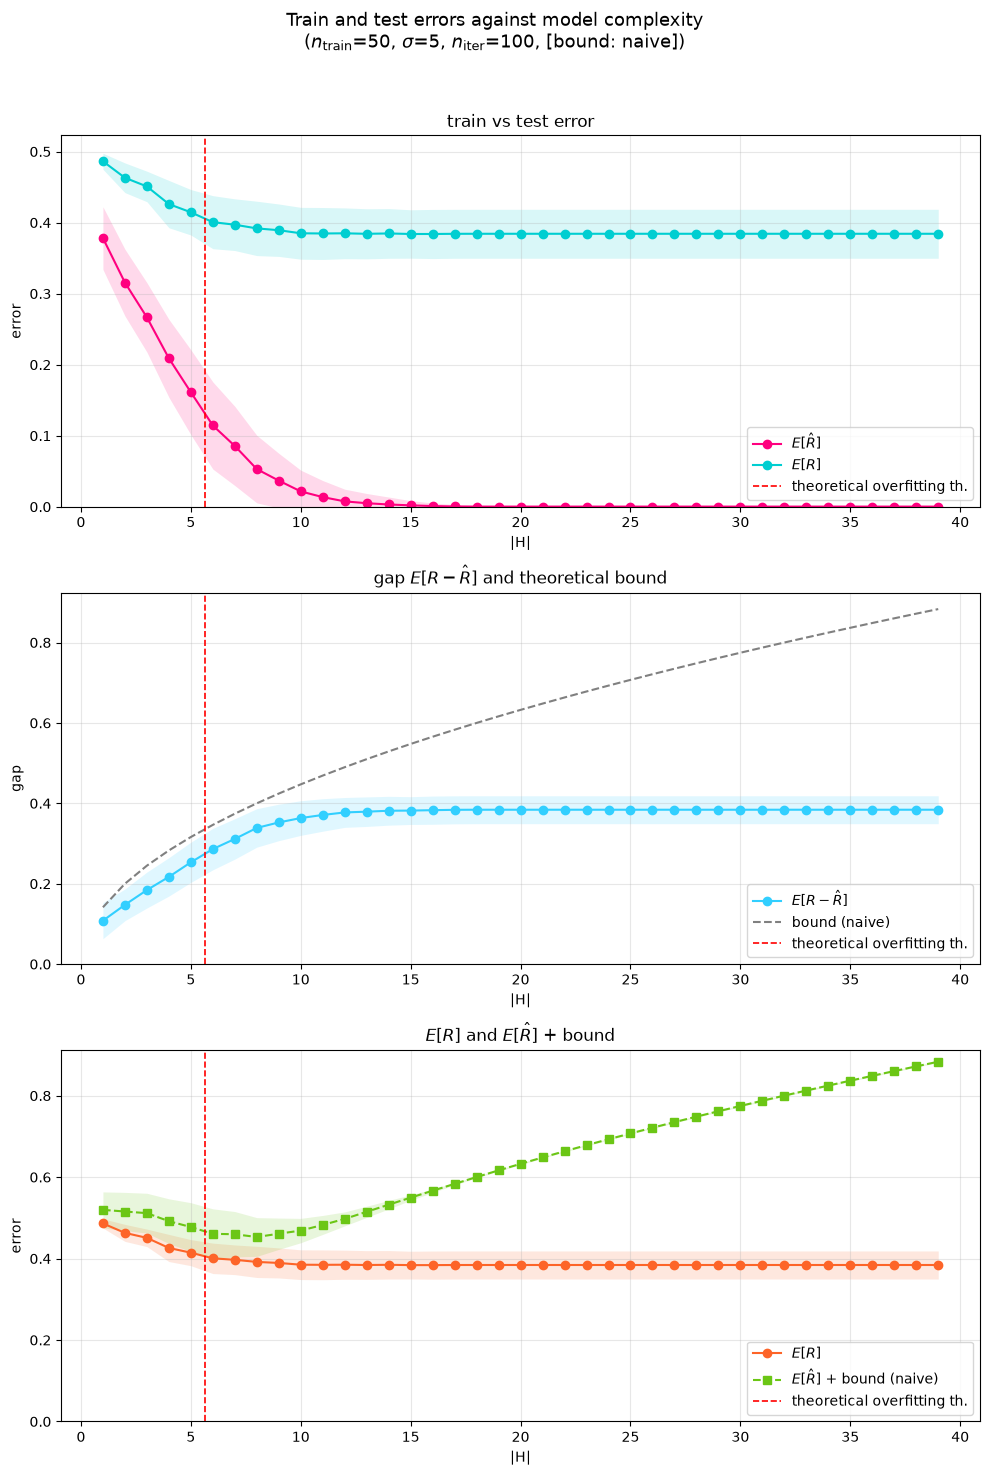

' \nRunning time: <1min\n'

In [5]:
# MODEL
mymodel = DecisionTreeClassifier

# PARAMETERS
N = 10_000
n_test = 200_000
n = 50
noise_std = 5
T = 100
m = 10

from functools import partial
mysine = partial(sine, num_crossings = m)

# build test set
x_test = sample_x(n_test, N)
y_test = sample_y(x = x_test, f = mysine, sigma = noise_std)

# build models and do plots
hat_Rs, Rs, gaps, std_hat_Rs, std_Rs, std_gaps, predictions, x, y, x_grid = main_loop(
    x_test, y_test, n_train = n, sigma = noise_std, num_iter = T, model = mymodel,
    fun = mysine
    )
plots(hat_Rs, Rs, gaps, std_hat_Rs=std_hat_Rs, std_Rs=std_Rs, std_gaps=std_gaps, 
      n_train = n, sigma = noise_std, num_iter= T, model = mymodel, 
      bound_name = "naive", bound_params = {}
      )

''' 
Running time: <1min
'''

**Bound with variance!** Equation (46)

[checkpoint] bound: "variance_trainerr" -> bound_variance_trainerror, params: ['Rhat']


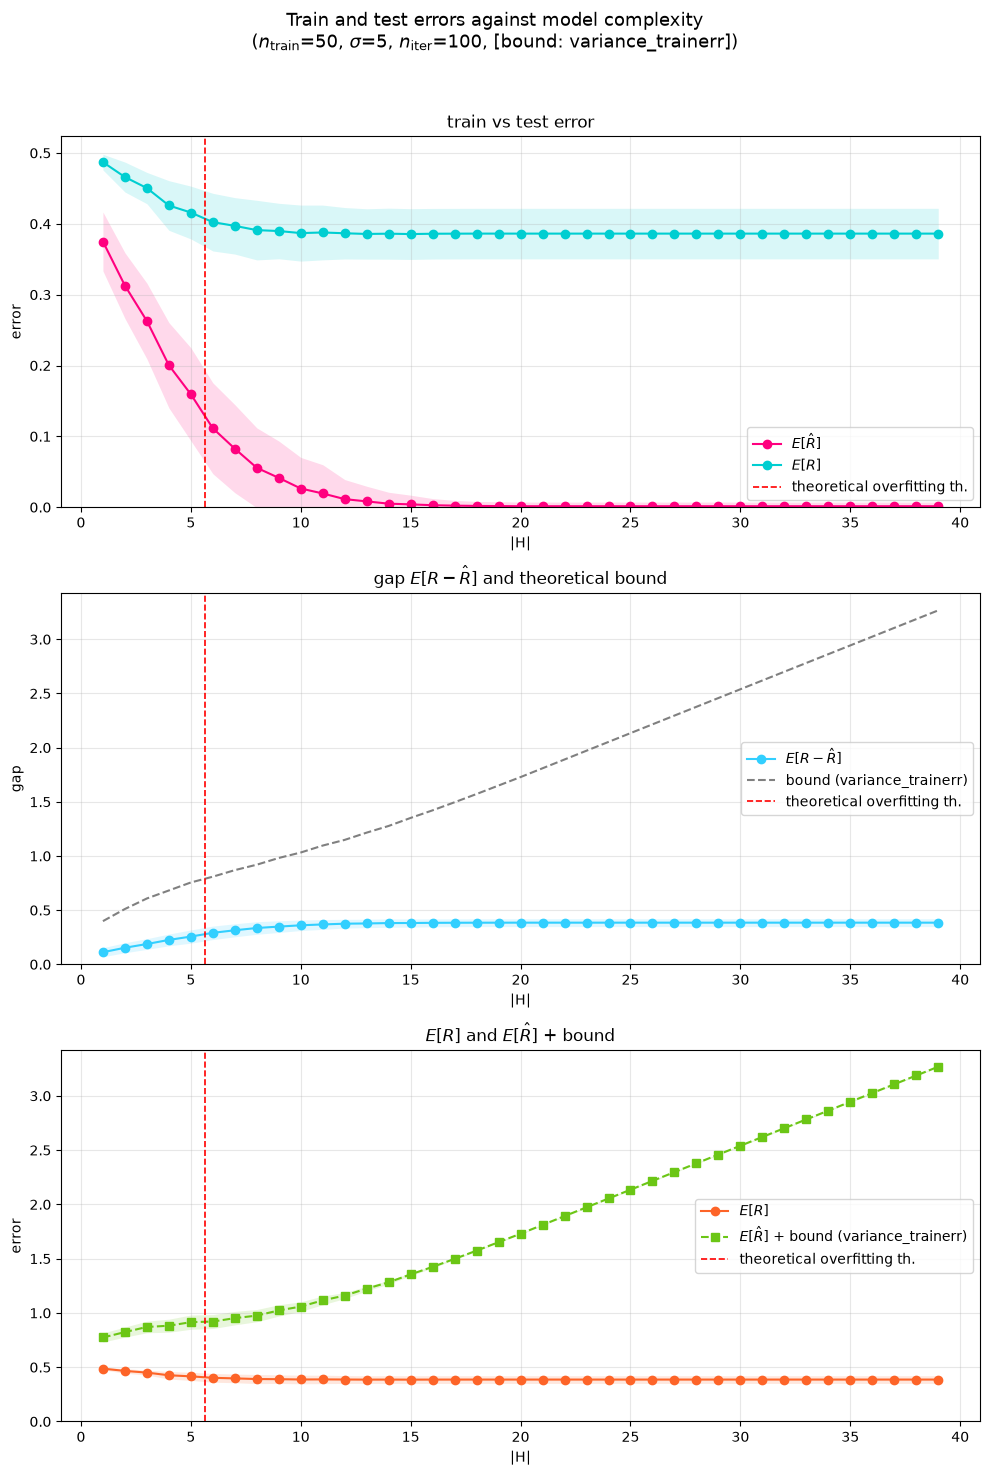

' \nRunning time: <1min\n'

In [11]:
# MODEL
mymodel = DecisionTreeClassifier

# PARAMETERS
N = 10_000
n_test = 200_000
n = 50
noise_std = 5
T = 100
m = 10

from functools import partial
mysine = partial(sine, num_crossings = m)

# build test set
x_test = sample_x(n_test, N)
y_test = sample_y(x = x_test, f = mysine, sigma = noise_std)

# build models and do plots
hat_Rs, Rs, gaps, std_hat_Rs, std_Rs, std_gaps, predictions, x, y, x_grid = main_loop(
    x_test, y_test, n_train = n, sigma = noise_std, num_iter = T, model = mymodel,
    fun = mysine
    )
plots(hat_Rs, Rs, gaps, std_hat_Rs=std_hat_Rs, std_Rs=std_Rs, std_gaps=std_gaps, 
      n_train = n, sigma = noise_std, num_iter= T, model = mymodel, 
      bound_name = "variance_trainerr", bound_params = {"Rhat" : hat_Rs}
      )

''' 
Running time: <1min
'''

conclusion: sto bound fa abba schifo perché dopo poco diventa esponenziale in $\vert\mathcal H\vert$. immagino che la stessa cosa accadrebbe per il $(47)$, quando $\inf R$ va a $0$. 

**Variance bound with $\inf R(f)$!** equation (47), con funzione seno

##### mia prova

In [ ]:
# compute inf R(f) exactly

import itertools
import numpy as np

N = 10,000
lower = 0
upper = 10

# indicator loss
def l(x,y):
    return 1*(x != y)

# uniform distribution
def p(x, N):
    return 1/N

inf_Rs = []
# per ogni depth fino al threshold dopo cui so che inf R = 0, cioe log2 N
for d in range(1, np.floor(np.log2(N)) + 1):
    print(f'Start with depth ',d)
    # set initial comparison R to infty to immeditaley store the first R as best_R
    best_R = np.inf
    # per ogni albero, che vuol dire ogni sequenza lunga 2^d di 1 e -1 -> NO! ogni albero è ogni sequenza e anche ogni possibile zona dello split!!!!
    for tree in itertools.product([1, -1], repeat=2**d):
        # calcolo per ogni 
        R = 0
        for x in range(np.linspace(lower, upper, N)):
            R += (l(x,1) + l(x,-1)) * p(x) # THIS IS WRONG because instead of x there should be f(x) which tells me which value is given to x
    if R < best_R:
        best_R = R
inf_Rs.append(best_R)

##### claude's + mio

In [7]:
import numpy as np
from scipy.stats import norm

def inf_R(fstar, sigma, N, depths, l=0., u=10.):
    x = np.linspace(l, u, N)
    fx = fstar(x)
    s = np.where(fx >= 0, 1, -1)
    # costi per etichetta +1 / -1 in ogni punto
    w = {c: norm.cdf(-c * fx / sigma) / N for c in (1, -1)}
    # comprimi in run di segno costante
    cuts = np.flatnonzero(np.diff(s)) + 1
    W = {c: np.add.reduceat(w[c], np.r_[0, cuts]) for c in (1, -1)}
    m = len(W[1])
    out = []
    for d in depths:
        K = min(2**int(d), m)   # più di m intervalli non servono
        dp = {c: np.full(K + 1, np.inf) for c in (1, -1)}   # dp[c][k]: k intervalli, ultimo etichettato c
        for c in (1, -1):
            dp[c][1] = W[c][0]
        for j in range(1, m):
            new = {}
            for c in (1, -1):
                stay = dp[c]                                  # stesso intervallo
                switch = np.r_[np.inf, dp[-c][:-1]]           # nuovo intervallo
                new[c] = np.minimum(stay, switch) + W[c][j]
            dp = new
        out.append(min(dp[1].min(), dp[-1].min()))
    return np.array(out)

[checkpoint] bound: "variance_inftesterr" -> bound_variance_inftesterror, params: ['inf_R']


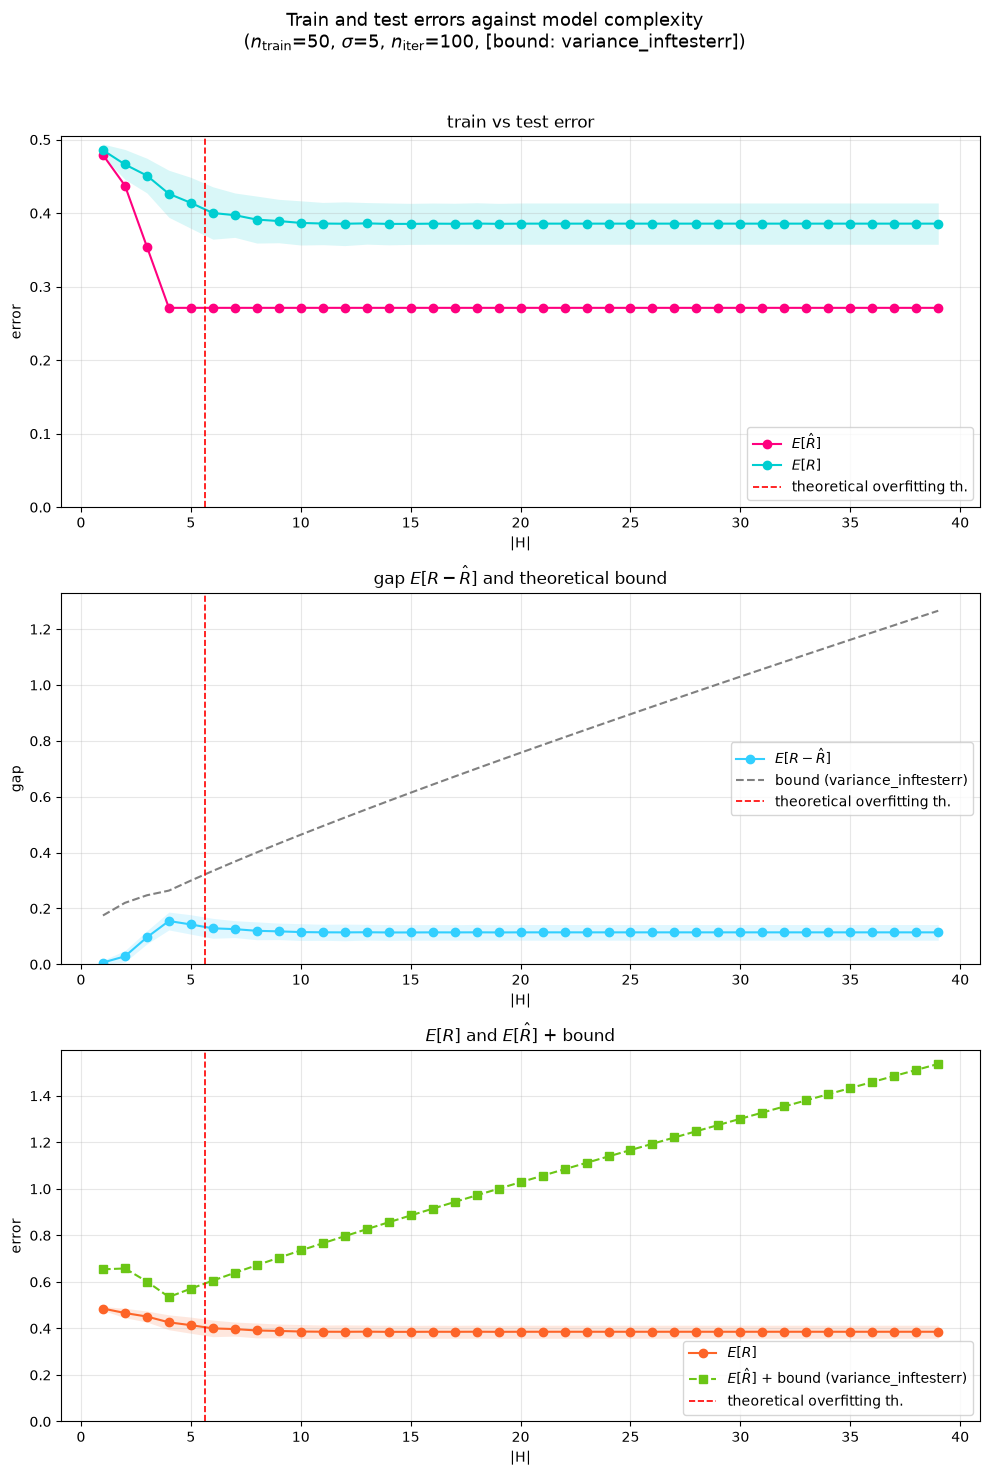

' \nRunning time: <1min\n'

In [14]:
# chiama main_loop() e plots(), dando a plots "E_hat_Rs" = inf_Rs, perché in questo bound cambia la LHS :) 

# MODEL
mymodel = DecisionTreeClassifier

# PARAMETERS
N = 10_000
n_test = 200_000
n = 50
noise_std = 5
T = 100
m = 10

from functools import partial
mysine = partial(sine, num_crossings = m)

# build test set
x_test = sample_x(n_test, N)
y_test = sample_y(x = x_test, f = mysine, sigma = noise_std)

# build models
_, Rs, _, std_hat_Rs, std_Rs, std_gaps, predictions, x, y, x_grid = main_loop(
    x_test, y_test, n_train = n, sigma = noise_std, num_iter = T, model = mymodel,
    fun = mysine
    )

# compute inf Rs
depths, _ = get_depths_list(np.log2(n), mymodel)

inf_Rs = inf_R(mysine, noise_std, N, depths)   # per sine: partial(sine, num_crossings=m)
gaps = Rs - inf_Rs

# do plots
plots(inf_Rs, Rs, gaps, std_hat_Rs=0, std_Rs=std_Rs, std_gaps=std_Rs, 
      n_train = n, sigma = noise_std, num_iter= T, model = mymodel, 
      bound_name = "variance_inftesterr", bound_params = {"inf_R" : inf_Rs}
      )

''' 
Running time: <1min
'''

concludiamo nuovamente che questo bound fa abbastanza schifo (ho provato anche con la parabola, è uguale)

**Bound with noise!** Equation (18) in the paper

In [18]:
from scipy.stats import norm

def h_of_alpha(fstar, sigma, alpha, N, l=0., u=10.):
    x = np.linspace(l, u, N)
    w = np.sort(np.abs(2*norm.cdf(fstar(x)/sigma) - 1))   # |2η-1| crescente
    P = np.arange(1, N+1) / N                               # P(f ≠ f*)
    exc = np.cumsum(w) / N                                   # min R(f) - R* a P fissato
    return np.min(exc / P**(1/alpha))

def noise_params(fstar, sigma, N, depths, alpha=0.5, l=0., u=10.):
    x = np.linspace(l, u, N)
    fx = fstar(x)
    m = 1 + np.count_nonzero(np.diff(np.where(fx >= 0, 1, -1)))   # run di segno costante
    h_bayes = h_of_alpha(fstar, sigma, alpha, N, l, u)              # non dipende da d
    alphas, hs = [], []
    for d in depths:
        if 2**int(d) >= m and h_bayes > 0:   # Bayes ∈ H_d e nessun punto con η = 1/2
            alphas.append(alpha); hs.append(h_bayes)
        else:                                 # solo α = 0 garantito, h irrilevante
            alphas.append(0.0); hs.append(1.0)
    return np.array(alphas), np.array(hs)

[checkpoint] bound: "noise" -> bound_noise, params: ['alpha', 'h']


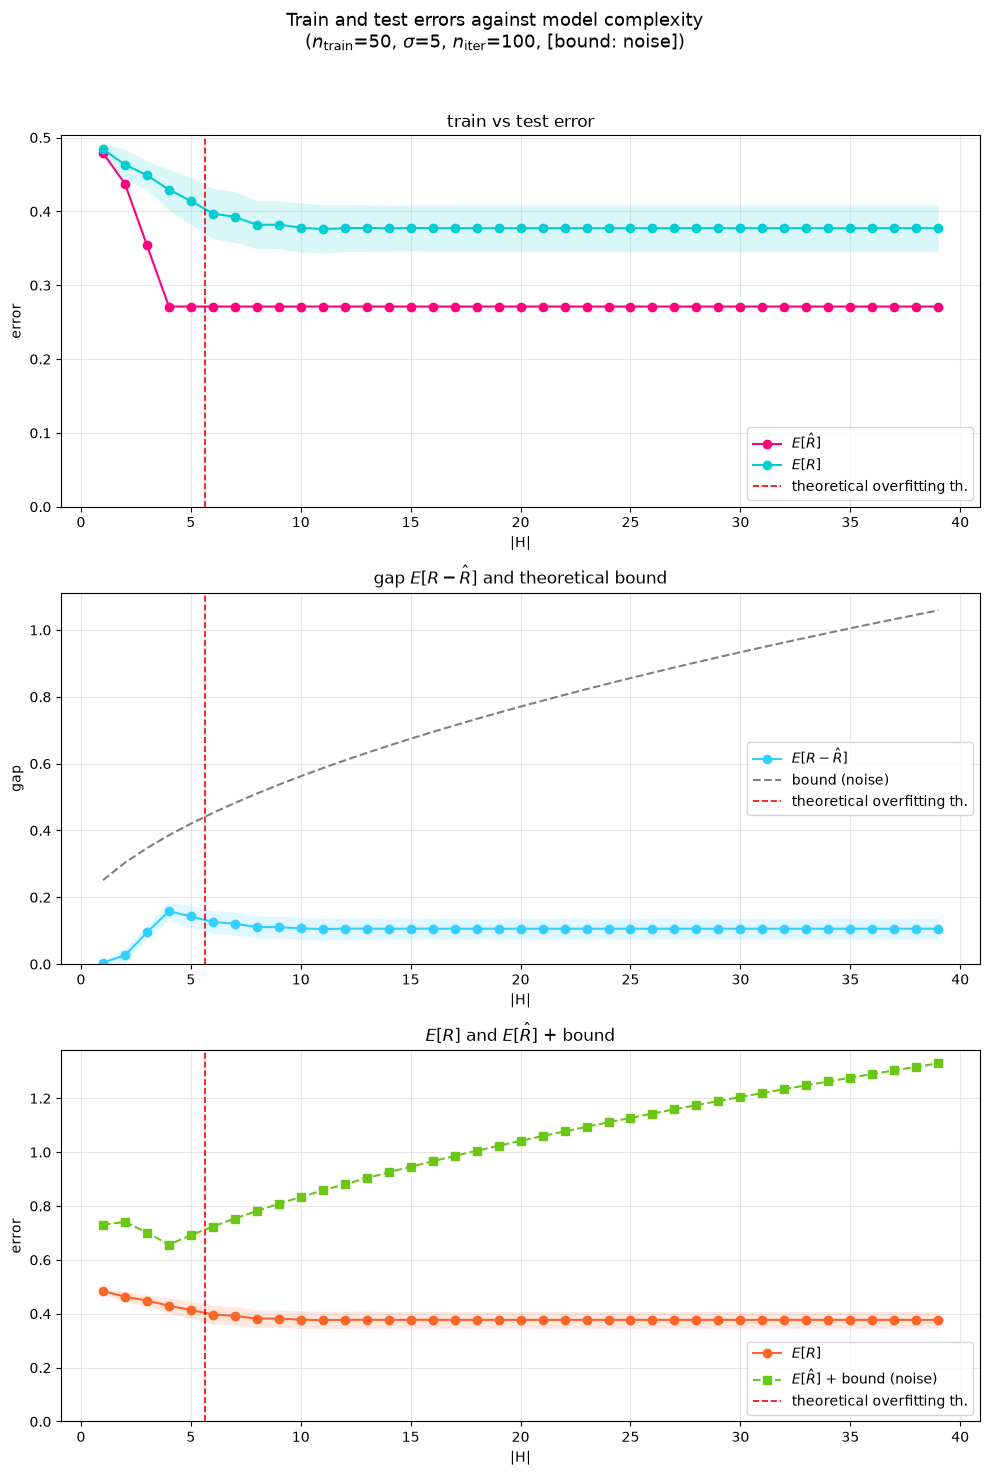

' \nRunning time: <1min\n'

In [21]:
# chiama main_loop() e plots(), dando a plots "E_hat_Rs" = inf_Rs, perché in questo bound cambia la LHS :) 

# MODEL
mymodel = DecisionTreeClassifier

# PARAMETERS
N = 10_000
n_test = 200_000
n = 50
noise_std = 5
T = 100
m = 10

from functools import partial
mysine = partial(sine, num_crossings = m)

# build test set
x_test = sample_x(n_test, N)
y_test = sample_y(x = x_test, f = mysine, sigma = noise_std)

# build models
_, Rs, _, _, std_Rs, _, predictions, x, y, x_grid = main_loop(
    x_test, y_test, n_train = n, sigma = noise_std, num_iter = T, model = mymodel,
    fun = mysine
    )

# compute inf Rs and noise params 
depths, _ = get_depths_list(np.log2(n), mymodel)

inf_Rs = inf_R(mysine, noise_std, N, depths)   # per sine: partial(sine, num_crossings=m)
gaps = Rs - inf_Rs

alphas, hs = noise_params(mysine, noise_std, N, depths)

# do plots
plots(inf_Rs, Rs, gaps, std_hat_Rs=0, std_Rs=std_Rs, std_gaps=std_Rs, 
      n_train = n, sigma = noise_std, num_iter= T, model = mymodel, 
      bound_name = "noise", bound_params = {"alpha": alphas, "h": hs}
      )

''' 
Running time: <1min
'''